# Standard Mode Results 27/05
22 09

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

### start

In [2]:
import matplotlib.patches as mpatches



def plot_pairwise_direction_significance_heatmap(
    pairwise_df: pd.DataFrame,
    feature_order: list[str],
    metric: str = "MCC",
    p_col: str = "p_adj",
    delta_col: str = "mean_delta_i_minus_j",
    feature_i_col: str = "feature_i",
    feature_j_col: str = "feature_j",
    figsize: tuple[float, float] = (9, 8),
    sig_threshold: float = 0.05,   # ← NEW: grey out non-significant cells
    max_logp: float | None = None,
    title_prefix: str | None = None,
    save_path: str | None = None,
):
    n = len(feature_order)
    score = pd.DataFrame(np.nan, index=feature_order, columns=feature_order)
    annot = pd.DataFrame("",    index=feature_order, columns=feature_order)
    seen  = set()  # ← duplicate guard

    for _, row in pairwise_df.iterrows():
        i, j = row[feature_i_col], row[feature_j_col]
        if i not in feature_order or j not in feature_order:
            print(f"[SKIP] unknown feature: {i!r} or {j!r}")
            continue

        p     = row[p_col]
        delta = row[delta_col]
        if pd.isna(p) or pd.isna(delta) or p <= 0:
            continue

        i_pos, j_pos = feature_order.index(i), feature_order.index(j)
        if i_pos == j_pos:
            continue

        # Canonicalise to upper triangle
        if i_pos < j_pos:
            row_feat, col_feat, signed_delta = i, j,  delta
        else:
            row_feat, col_feat, signed_delta = j, i, -delta

        pair_key = (row_feat, col_feat)
        if pair_key in seen:                          # ← duplicate guard
            print(f"[WARN] duplicate pair {pair_key}, keeping first.")
            continue
        seen.add(pair_key)

        logp         = -np.log10(p)
        signed_score = np.sign(signed_delta) * logp

        # ← Grey out non-significant: set score to 0 so it maps to white
        if p >= sig_threshold:
            signed_score = 0.0

        score.loc[row_feat, col_feat] = signed_score

        # Annotation: p-value + stars
        stars = (
            "***" if p < 0.001 else
            "**"  if p < 0.01  else
            "*"   if p < 0.05  else
            "ns"
        )
        annot.loc[row_feat, col_feat] = f"{p:.1e}\n{stars}"

    if max_logp is None:
        max_abs = np.nanmax(np.abs(score.values))
        max_logp = max_abs if np.isfinite(max_abs) and max_abs > 0 else 1.0

    # Mask everything except upper triangle
    mask = pd.DataFrame(True, index=feature_order, columns=feature_order)
    for r in range(n):
        for c in range(r + 1, n):           # strict upper triangle only
            mask.iloc[r, c] = False         # unmask upper triangle
    # Also unmask cells that were explicitly filled (handles non-square edge cases)
    mask = mask | score.isna()

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        score,
        mask=mask,
        annot=annot,
        fmt="",
        cmap="RdBu",
        center=0,
        vmin=-max_logp,
        vmax=max_logp,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": r"$\mathrm{sign}(\Delta) \times -\log_{10}(p)$"},
    )

    ax.set_title(f"{title_prefix} Pairwise Wilcoxon comparisons - {metric}", fontsize=18)
    ax.set_xlabel("Column model (j)", fontsize=17)
    ax.set_ylabel("Row model (i)", fontsize=17)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # one-liner
    ax.tick_params(axis="y", rotation=0, labelsize=13)
    ax.tick_params(axis="x", labelsize=13 )

    # Manual legend for direction + ns
    handles = [
        mpatches.Patch(color="#2166ac", label="Row model better (blue)"),
        mpatches.Patch(color="#d6604d", label="Column model better (red)"),
        mpatches.Patch(color="#f7f7f7", label=f"ns (p ≥ {sig_threshold})"),
    ]
    ax.legend(handles=handles, loc="lower left",
              bbox_to_anchor=(0, -0.35), ncol=3, fontsize=11, frameon=False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax, score, annot

In [2]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results"

v1 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_disease_27_05.parquet"))
v1


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error
0,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.874537,0.616455,0.799280,...,0.890255,0.800000,0.089448,3.0,raw_lognorm,None,None,NaN,None,None
1,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.728704,0.582476,0.780251,...,0.813213,0.466667,0.300422,3.0,raw_pca50,None,None,NaN,None,None
2,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.531019,0.032225,0.452417,...,0.576868,0.400000,0.153523,3.0,random_proj50,None,None,NaN,None,None
3,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.791204,0.329086,0.597729,...,0.801434,0.739437,0.062726,3.0,obsm[scvi],None,None,NaN,None,None
4,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.816204,0.328499,0.559262,...,0.773426,0.675676,0.139623,3.0,obsm[geneformer],None,None,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32484,fold_4,70070.0,31908.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NaN,NaN,NaN,...,0.299462,0.226936,0.072439,3.0,random_proj50,single_class_after_filtering,None,NaN,None,None
32485,fold_4,70070.0,31908.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NaN,NaN,NaN,...,0.022682,0.014973,0.010686,3.0,obsm[scvi],single_class_after_filtering,None,NaN,None,None
32486,fold_4,70070.0,31908.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NaN,NaN,NaN,...,0.095435,0.013234,0.074274,3.0,obsm[geneformer],single_class_after_filtering,None,NaN,None,None
32487,fold_4,70070.0,31908.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NaN,NaN,NaN,...,0.031607,0.000076,0.034221,3.0,obsm[tf-sapiens],single_class_after_filtering,None,NaN,None,None


In [3]:
pd.crosstab(v1.dataset_id, v1.feature)

feature,obsm[bmfm],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55,55,55,55,55,55,55,55
07760522-707a-4a1c-8891-dbd1226d6b27,0,4,4,4,4,4,4,4
0b75c598-0893-4216-afe8-5414cab7739d,27,27,27,27,27,27,27,27
0bc7235a-ae5a-479d-a487-510435377e55,30,30,30,30,30,30,30,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29,29,29,29,29,29,29,29
...,...,...,...,...,...,...,...,...
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115,115,115,115,115,115,115,115
f1606894-59df-4794-a37f-baa7c6fb6de1,55,55,55,55,55,55,55,55
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,0,4,4,4,4,4,4,4


In [130]:
pd.crosstab(v1.task_id, v1.feature)

AttributeError: 'DataFrame' object has no attribute 'task_id'

In [127]:
v1.query('dataset_id=="f5be4b96-f5a3-4c3d-84ac-6f69daf744d5"')

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error
7738,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.550933,0.120037,0.457393,...,0.550933,0.249467,0.426337,2.0,raw_lognorm,NA,NA,NA,NA,NA
7739,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.633066,0.265322,0.589177,...,0.633066,0.469083,0.231906,2.0,raw_pca50,NA,NA,NA,NA,NA
7740,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.542172,0.081537,0.535896,...,0.542172,0.512915,0.041375,2.0,random_proj50,NA,NA,NA,NA,NA
7741,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.505559,0.010824,0.503371,...,0.505559,0.435424,0.099185,2.0,obsm[scvi],NA,NA,NA,NA,NA
7742,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.521755,0.042485,0.519719,...,0.521755,0.446494,0.106434,2.0,obsm[geneformer],NA,NA,NA,NA,NA
7743,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.642452,0.299909,0.576445,...,0.642452,0.402985,0.338657,2.0,obsm[tf-sapiens],NA,NA,NA,NA,NA
7744,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.523344,0.047374,0.479455,...,0.523344,0.360341,0.230521,2.0,obsm[tf-exemplar-human],NA,NA,NA,NA,NA
7745,fold_2,5009.0,1802.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,NA,NA,NA,...,0.560131,0.496732,0.089659,2.0,raw_lognorm,single_class_after_filtering,NA,NA,NA,NA
7746,fold_2,5009.0,1802.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,NA,NA,NA,...,0.42533,0.170661,0.360157,2.0,raw_pca50,single_class_after_filtering,NA,NA,NA,NA
7747,fold_2,5009.0,1802.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,NA,NA,NA,...,0.496282,0.468235,0.039664,2.0,random_proj50,single_class_after_filtering,NA,NA,NA,NA


In [128]:
v1[(v1['dataset_id']=="f5be4b96-f5a3-4c3d-84ac-6f69daf744d5" )& (v1['feature']=='raw_lognorm')]

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error
7738,fold_1,6071.0,740.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.550933,0.120037,0.457393,...,0.550933,0.249467,0.426337,2.0,raw_lognorm,NA,NA,NA,NA,NA
7745,fold_2,5009.0,1802.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,NA,NA,NA,...,0.560131,0.496732,0.089659,2.0,raw_lognorm,single_class_after_filtering,NA,NA,NA,NA
7752,fold_3,3974.0,2837.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.636674,0.19381,0.367707,...,0.484809,0.124573,0.431454,3.0,raw_lognorm,NA,NA,NA,NA,NA
7759,fold_4,5379.0,1432.0,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,26994,0.293321,-0.408086,0.283572,...,0.248068,0.0,0.218523,3.0,raw_lognorm,NA,NA,NA,NA,NA


In [129]:
v1[(v1['dataset_id']=="edc8d3fe-153c-4e3d-8be0-2108d30f8d70" )& (v1['feature']=='raw_lognorm')]

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error
9167,fold_1,1984.0,1057.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,naive B cell,18854,0.628769,0.405782,0.608925,...,0.720729,0.226562,0.355604,4.0,raw_lognorm,NA,NA,NA,NA,NA
9175,fold_2,2987.0,54.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,naive B cell,18854,0.577778,0.17259,0.29533,...,0.577778,0.155556,0.597112,2.0,raw_lognorm,NA,NA,NA,NA,NA
9183,fold_3,3008.0,33.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,naive B cell,18854,0.947368,0.884813,0.938889,...,0.947368,0.894737,0.074432,2.0,raw_lognorm,NA,NA,NA,NA,NA
9191,fold_4,1750.0,1291.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,naive B cell,18854,0.928683,0.189501,0.501804,...,0.84905,0.360731,0.238549,7.0,raw_lognorm,NA,NA,NA,NA,NA
9199,fold_5,2435.0,606.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,naive B cell,18854,0.58156,0.342503,0.62132,...,0.756122,0.114286,0.355243,7.0,raw_lognorm,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25744,fold_1,1101.0,78.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,"CD4-positive, alpha-beta memory T cell",17089,0.474026,-0.026495,0.483444,...,0.629252,0.0,0.545163,3.0,raw_lognorm,NA,NA,NA,NA,NA
25752,fold_2,1170.0,9.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,"CD4-positive, alpha-beta memory T cell",17089,NA,NA,NA,...,0.428571,0.0,0.515079,3.0,raw_lognorm,single_class_after_filtering,NA,NA,NA,NA
25760,fold_3,805.0,374.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,"CD4-positive, alpha-beta memory T cell",17089,0.944892,0.203434,0.515284,...,0.963262,0.889785,0.063633,3.0,raw_lognorm,NA,NA,NA,NA,NA
25768,fold_4,945.0,234.0,NA,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,"CD4-positive, alpha-beta memory T cell",17089,0.655702,0.288938,0.643956,...,0.594493,0.0,0.483991,4.0,raw_lognorm,NA,NA,NA,NA,NA


In [4]:

v2 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_disease_27_05_v2.parquet"))
v2


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,std_donor_acc,n_valid_donors,AUROC,AUPRC,feature,skip_reason,donor_metric_error,error,proba_unavailable,AUROC_ovr
0,fold_1,14995.0,3850.0,None,6cf3634d-e911-44ad-bf52-c747a9af3c01,fibroblast,21978.0,NaN,NaN,NaN,...,0.472434,2.0,NaN,NaN,obsm[bmfm_var1],None,None,None,None,NaN
1,fold_2,16952.0,1893.0,None,6cf3634d-e911-44ad-bf52-c747a9af3c01,fibroblast,21978.0,0.680026,0.547128,0.723831,...,0.259696,6.0,0.873369,0.789383,obsm[bmfm_var1],None,None,None,None,NaN
2,fold_3,16364.0,2481.0,None,6cf3634d-e911-44ad-bf52-c747a9af3c01,fibroblast,21978.0,0.634993,0.456315,0.653090,...,0.399854,5.0,0.748030,0.626367,obsm[bmfm_var1],None,None,None,None,NaN
3,fold_4,8224.0,10621.0,None,6cf3634d-e911-44ad-bf52-c747a9af3c01,fibroblast,21978.0,0.691223,0.412819,0.603094,...,0.360394,9.0,0.693782,0.471373,obsm[bmfm_var1],None,None,None,None,NaN
4,None,NaN,NaN,None,f8d8b443-bca6-4c3c-9042-669dfb7f8030,microglial cell,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,all_folds_degenerate,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3906,fold_1,3400.0,736.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,NaN,NaN,NaN,...,0.189755,3.0,NaN,NaN,obsm[bmfm_var1],None,None,None,None,NaN
3907,fold_2,3326.0,810.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.552055,0.107052,0.513687,...,0.255735,3.0,0.562398,0.644565,obsm[bmfm_var1],None,None,None,None,NaN
3908,fold_3,3032.0,1104.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.647736,0.177730,0.547404,...,0.160960,3.0,0.645924,0.950920,obsm[bmfm_var1],None,None,None,None,NaN
3909,fold_4,3317.0,819.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.650223,0.226853,0.534539,...,0.195467,3.0,0.666133,0.884669,obsm[bmfm_var1],None,None,None,None,NaN


In [104]:
v2.fillna('NA', inplace=True)


/sci/backup/dandanbz/haya.benhayon/tmp/ipykernel_350741/2168842343.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  v2.fillna('NA', inplace=True)


In [118]:
v1.fillna('NA', inplace=True)


/sci/backup/dandanbz/haya.benhayon/tmp/ipykernel_350741/2095583713.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  v1.fillna('NA', inplace=True)


In [108]:

len(missing)

12

In [119]:
max(v1.query('dataset_id.isin(@missing)').balanced_acc)

TypeError: '>' not supported between instances of 'float' and 'str'

In [121]:
v1.query('dataset_id.isin(@missing)')

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error
6395,fold_1,18513.0,4684.0,NA,9813a1d4-d107-459e-9b2e-7687be935f69,inhibitory interneuron,27807,NA,NA,NA,...,0.899844,0.82776,0.063622,3.0,raw_lognorm,single_class_after_filtering,NA,NA,NA,NA
6396,fold_1,18513.0,4684.0,NA,9813a1d4-d107-459e-9b2e-7687be935f69,inhibitory interneuron,27807,NA,NA,NA,...,0.85333,0.74164,0.105378,3.0,raw_pca50,single_class_after_filtering,NA,NA,NA,NA
6397,fold_1,18513.0,4684.0,NA,9813a1d4-d107-459e-9b2e-7687be935f69,inhibitory interneuron,27807,NA,NA,NA,...,0.593923,0.580584,0.012775,3.0,random_proj50,single_class_after_filtering,NA,NA,NA,NA
6398,fold_1,18513.0,4684.0,NA,9813a1d4-d107-459e-9b2e-7687be935f69,inhibitory interneuron,27807,NA,NA,NA,...,0.560397,0.452588,0.096582,3.0,obsm[scvi],single_class_after_filtering,NA,NA,NA,NA
6399,fold_1,18513.0,4684.0,NA,9813a1d4-d107-459e-9b2e-7687be935f69,inhibitory interneuron,27807,NA,NA,NA,...,0.884882,0.842601,0.052079,3.0,obsm[geneformer],single_class_after_filtering,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32484,fold_4,70070.0,31908.0,NA,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NA,NA,NA,...,0.299462,0.226936,0.072439,3.0,random_proj50,single_class_after_filtering,NA,NA,NA,NA
32485,fold_4,70070.0,31908.0,NA,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NA,NA,NA,...,0.022682,0.014973,0.010686,3.0,obsm[scvi],single_class_after_filtering,NA,NA,NA,NA
32486,fold_4,70070.0,31908.0,NA,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NA,NA,NA,...,0.095435,0.013234,0.074274,3.0,obsm[geneformer],single_class_after_filtering,NA,NA,NA,NA
32487,fold_4,70070.0,31908.0,NA,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,NA,NA,NA,...,0.031607,0.000076,0.034221,3.0,obsm[tf-sapiens],single_class_after_filtering,NA,NA,NA,NA


In [120]:
v1.query('dataset_id.isin(@missing)').describe()

,n_genes
count,343.000000
mean,28160.142857
std,2052.086344
min,22788.000000
25%,26994.000000
50%,28061.000000
75%,29453.000000
max,31708.000000


In [111]:
v2.query('dataset_id.isin(@missing)')

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,std_donor_acc,n_valid_donors,AUROC,AUPRC,feature,skip_reason,donor_metric_error,error,proba_unavailable,AUROC_ovr
4,NA,NA,NA,NA,f8d8b443-bca6-4c3c-9042-669dfb7f8030,microglial cell,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
33,NA,NA,NA,NA,4dd1cd23-fc4d-4fd1-9709-602540f3ca6f,oligodendrocyte precursor cell,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
34,NA,NA,NA,NA,f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,endothelial cell,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
43,NA,NA,NA,NA,2856d06c-0ff9-4e01-bfc9-202b74d0b60f,dopaminergic neuron,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
157,NA,NA,NA,NA,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
281,NA,NA,NA,NA,9813a1d4-d107-459e-9b2e-7687be935f69,inhibitory interneuron,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
347,NA,NA,NA,NA,85c60876-7f35-40c5-a256-7808d84c6ba5,neuron,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
1350,NA,NA,NA,NA,a19d1667-a7b5-4556-9e5f-f9bfa690c0f1,skin fibroblast,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
1960,NA,NA,NA,NA,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA
1969,NA,NA,NA,NA,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,all_folds_degenerate,NA,NA,NA,NA


In [107]:
ct = pd.crosstab(v2.dataset_id, v2.feature)

# dataset_ids missing (count==0) for both columns
missing = ct[(ct['NA'] == 1) ].index.tolist()
print(missing)

['07760522-707a-4a1c-8891-dbd1226d6b27', '251b1a7e-d050-4486-8d50-4c2619eb0f46', '2856d06c-0ff9-4e01-bfc9-202b74d0b60f', '4dd1cd23-fc4d-4fd1-9709-602540f3ca6f', '5829c7ba-697f-418e-8b98-d605b192dc48', '85c60876-7f35-40c5-a256-7808d84c6ba5', '9813a1d4-d107-459e-9b2e-7687be935f69', 'a19d1667-a7b5-4556-9e5f-f9bfa690c0f1', 'a1b9c51e-a408-4f7f-bccb-abefe20ae2a5', 'e40c6272-af77-4a10-9385-62a398884f27', 'f5be4b96-f5a3-4c3d-84ac-6f69daf744d5', 'f8d8b443-bca6-4c3c-9042-669dfb7f8030']


In [5]:
pd.crosstab(v2.dataset_id, v2.feature)

feature,obsm[bmfm_var1]
dataset_id,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55
0b75c598-0893-4216-afe8-5414cab7739d,27
0bc7235a-ae5a-479d-a487-510435377e55,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29
19e46756-9100-4e01-8b0e-23b557558a4c,35
...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,115
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,75
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115


In [103]:
v2[v2.feature=='obsm[bmfm_var1]'].metric_error.unique()

array(['single_class_after_filtering', None], dtype=object)

In [95]:
v1[~v1['dataset_id'].isin(v2.dataset_id)]

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error


In [6]:

v3 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_disease_27_05_v3.parquet"))
v3


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,worst_donor_acc,std_donor_acc,n_valid_donors,feature,proba_unavailable,skip_reason,metric_error,error,AUROC_ovr,donor_metric_error
0,fold_1,451364.0,119553.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,L2/3-6 intratelencephalic projecting glutamate...,35646.0,0.563784,0.127629,0.563760,...,0.359062,0.146272,17.0,obsm[bmfm_WCED10],None,None,None,None,NaN,None
1,fold_1,451364.0,119553.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,L2/3-6 intratelencephalic projecting glutamate...,35646.0,0.598689,0.197444,0.598424,...,0.136169,0.244386,17.0,obsm[bmfm_MLMMUL],None,None,None,None,NaN,None
2,fold_2,432076.0,138841.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,L2/3-6 intratelencephalic projecting glutamate...,35646.0,0.568485,0.131390,0.560517,...,0.320879,0.157873,19.0,obsm[bmfm_WCED10],None,None,None,None,NaN,None
3,fold_2,432076.0,138841.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,L2/3-6 intratelencephalic projecting glutamate...,35646.0,0.576942,0.148248,0.570451,...,0.300195,0.180397,19.0,obsm[bmfm_MLMMUL],None,None,None,None,NaN,None
4,fold_3,462283.0,108634.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,L2/3-6 intratelencephalic projecting glutamate...,35646.0,0.587184,0.173462,0.586310,...,0.279371,0.226831,17.0,obsm[bmfm_WCED10],None,None,None,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7789,fold_3,3032.0,1104.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.589369,0.101718,0.501735,...,0.448718,0.173175,3.0,obsm[bmfm_MLMMUL],None,None,None,None,NaN,None
7790,fold_4,3317.0,819.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.573684,0.111422,0.496031,...,0.328671,0.158849,3.0,obsm[bmfm_WCED10],None,None,None,None,NaN,None
7791,fold_4,3317.0,819.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.566168,0.099928,0.484417,...,0.286713,0.180126,3.0,obsm[bmfm_MLMMUL],None,None,None,None,NaN,None
7792,fold_5,3469.0,667.0,None,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35,"CD8-positive, alpha-beta T cell",27313.0,0.643888,0.282210,0.630608,...,0.321244,0.233562,4.0,obsm[bmfm_WCED10],None,None,None,None,NaN,None


In [7]:
pd.crosstab(v3.dataset_id, v3.feature)

feature,obsm[bmfm_MLMMUL],obsm[bmfm_WCED10]
dataset_id,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55,55
0b75c598-0893-4216-afe8-5414cab7739d,27,27
0bc7235a-ae5a-479d-a487-510435377e55,30,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29,29
19e46756-9100-4e01-8b0e-23b557558a4c,35,35
...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,115,115
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,75,75
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115,115


In [10]:

v9 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_disease_27_05_9.parquet"))
v9


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,recall_macro_donor,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,metric_error,feature,proba_unavailable,AUROC_ovr,error
0,fold_1,31868.0,12751.0,None,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.476059,-0.043261,0.424726,...,0.50,0.476059,0.387473,0.125279,2.0,None,obsm[bmfm],None,NaN,None
1,fold_1,31868.0,12751.0,None,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.656287,0.341339,0.666654,...,0.50,0.656287,0.436236,0.311200,2.0,None,obsm[bmfm_WCED10],None,NaN,None
2,fold_1,31868.0,12751.0,None,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.220414,-0.533749,0.192269,...,0.00,0.220414,0.163490,0.080502,2.0,None,obsm[bmfm_MLMMUL],None,NaN,None
3,fold_1,31868.0,12751.0,None,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.346434,-0.271979,0.346002,...,0.00,0.346434,0.263852,0.116788,2.0,None,obsm[bmfm_var1],None,NaN,None
4,fold_2,24678.0,19941.0,None,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,NaN,NaN,NaN,...,0.25,0.314899,0.054661,0.368032,2.0,single_class_after_filtering,obsm[bmfm],None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,fold_2,8529.0,7570.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788,0.621053,0.422443,0.664196,...,0.50,0.866313,0.249224,0.302690,6.0,None,obsm[bmfm_var1],None,NaN,None
920,fold_3,10691.0,5408.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788,0.657650,0.432132,0.695559,...,0.50,0.854885,0.340881,0.257730,6.0,None,obsm[bmfm],None,NaN,None
921,fold_3,10691.0,5408.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788,0.752897,0.649126,0.806526,...,1.00,0.902194,0.514465,0.192762,6.0,None,obsm[bmfm_WCED10],None,NaN,None
922,fold_3,10691.0,5408.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788,0.615520,0.276103,0.632220,...,0.50,0.847872,0.294340,0.280016,6.0,None,obsm[bmfm_MLMMUL],None,NaN,None


In [11]:
pd.crosstab(v9.dataset_id, v9.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1]
dataset_id,,,,
07760522-707a-4a1c-8891-dbd1226d6b27,4,4,4,4
13b61a7d-5605-4948-ba48-02c588960143,10,10,10,10
251b1a7e-d050-4486-8d50-4c2619eb0f46,4,4,4,4
2856d06c-0ff9-4e01-bfc9-202b74d0b60f,4,4,4,4
3966ba97-beb8-4d0b-9954-d3775cd2cd61,7,7,7,7
4dd1cd23-fc4d-4fd1-9709-602540f3ca6f,4,4,4,4
576f193c-75d0-4a11-bd25-8676587e6dc2,29,29,29,29
5829c7ba-697f-418e-8b98-d605b192dc48,4,4,4,4
6a270451-b4d9-43e0-aa89-e33aac1ac74b,21,21,21,21


In [ ]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results"

# Get all parquet files
files = glob.glob(os.path.join(dir_path, "*.parquet"))

# Read and concatenate
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df

In [12]:

df = pd.concat([v1, v2 ,v3, v9], ignore_index=True)
df

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,balanced_acc,MCC,F1_macro,...,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,error,AUROC_ovr,proba_unavailable,donor_metric_error,skip_reason
0,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.874537,0.616455,0.799280,...,0.800000,0.089448,3.0,raw_lognorm,None,None,NaN,None,None,NaN
1,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.728704,0.582476,0.780251,...,0.466667,0.300422,3.0,raw_pca50,None,None,NaN,None,None,NaN
2,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.531019,0.032225,0.452417,...,0.400000,0.153523,3.0,random_proj50,None,None,NaN,None,None,NaN
3,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.791204,0.329086,0.597729,...,0.739437,0.062726,3.0,obsm[scvi],None,None,NaN,None,None,NaN
4,fold_1,499.0,231.0,None,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.816204,0.328499,0.559262,...,0.675676,0.139623,3.0,obsm[geneformer],None,None,NaN,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45113,fold_2,8529.0,7570.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788.0,0.621053,0.422443,0.664196,...,0.249224,0.302690,6.0,obsm[bmfm_var1],None,None,NaN,None,NaN,NaN
45114,fold_3,10691.0,5408.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788.0,0.657650,0.432132,0.695559,...,0.340881,0.257730,6.0,obsm[bmfm],None,None,NaN,None,NaN,NaN
45115,fold_3,10691.0,5408.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788.0,0.752897,0.649126,0.806526,...,0.514465,0.192762,6.0,obsm[bmfm_WCED10],None,None,NaN,None,NaN,NaN
45116,fold_3,10691.0,5408.0,None,a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,microglial cell,22788.0,0.615520,0.276103,0.632220,...,0.294340,0.280016,6.0,obsm[bmfm_MLMMUL],None,None,NaN,None,NaN,NaN


In [13]:
pd.crosstab(df.dataset_id, df.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55,55,55,55,55,55,55,55,55,55,55
07760522-707a-4a1c-8891-dbd1226d6b27,4,4,4,4,4,4,4,4,4,4,4
0b75c598-0893-4216-afe8-5414cab7739d,27,27,27,27,27,27,27,27,27,27,27
0bc7235a-ae5a-479d-a487-510435377e55,30,30,30,30,30,30,30,30,30,30,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29,29,29,29,29,29,29,29,29,29,29
...,...,...,...,...,...,...,...,...,...,...,...
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115,115,115,115,115,115,115,115,115,115,115
f1606894-59df-4794-a37f-baa7c6fb6de1,55,55,55,55,55,55,55,55,55,55,55
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,4,4,4,4,4,4,4,4,4,4,4


In [14]:
df.to_parquet("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results/test_files_standard_disease_27_05_final.parquet")

## 2. Load and Prepare Results

In [28]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results/test_files_standard_disease_27_05_final.parquet"
df = load_and_prepare_results(parquet_path)

print(f"After filtering (errors/skips removed):")
print(f"  Total rows: {len(df):,}")
print(f"  Unique tasks: {df['task_id'].nunique()}")
print(f"  Features: {sorted(df['feature_clean'].unique())}")
print(f"\nSample:")
df[['task_id', 'fold', 'feature_clean', 'MCC', 'balanced_acc', 'F1_macro']].head(9)

After filtering (errors/skips removed):
  Total rows: 44,882
  Unique tasks: 868
  Features: ['BMFM-CONCAT', 'BMFM_BW', 'BMFM_LM', 'BMFM_LW', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-EXEMPLAR-HUMAN', 'TF-SAPIENS', 'random_proj50']

Sample:


,task_id,fold,feature_clean,MCC,balanced_acc,F1_macro
0,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,Raw Log-norm,0.616455,0.874537,0.799280
1,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,PCA-50,0.582476,0.728704,0.780251
2,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,random_proj50,0.032225,0.531019,0.452417
3,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,SCVI,0.329086,0.791204,0.597729
4,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,GENEFORMER,0.328499,0.816204,0.559262
5,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,TF-SAPIENS,0.187736,0.689352,0.465067
6,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,TF-EXEMPLAR-HUMAN,0.222735,0.725926,0.445689
7,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,BMFM_LW,0.096896,0.584259,0.509059
8,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_2,Raw Log-norm,0.629902,0.814951,0.814951


In [29]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM-CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [30]:
df= df.query('feature_clean.isin(@feature_order)')

In [31]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

## rank-based Demšar-style

### freidman corrected 20 08

In [32]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar)

Datasets before dropna: 82, after: 82 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (82, 7)  (T=82 datasets, M=7 models)

=== Friedman Test ===
T=82 tasks, M=7 models
Chi² = 194.9111, p = 2.2966e-39
Iman-Davenport F = 53.1417, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
Raw Log-norm     2.6220
TF-SAPIENS       2.7195
PCA-50           2.8659
BMFM-CONCAT      3.8293
GENEFORMER       4.5976
SCVI             5.3537
random_proj50    6.0122
Nemenyi CD (alpha=0.05, M=7, T=82): 0.9949
Disease average ranks (dataset-corrected):
feature_clean
Raw Log-norm     2.622
TF-SAPIENS       2.720
PCA-50           2.866
BMFM-CONCAT      3.829
GENEFORMER       4.598
SCVI             5.354
random_proj50    6.012
dtype: float64
T = 82 (datasets, not tasks)

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_d

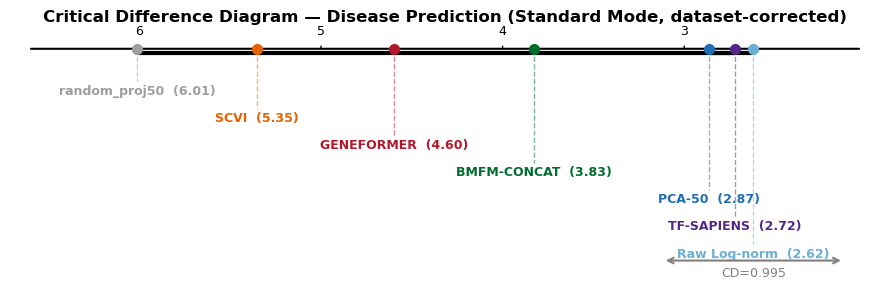

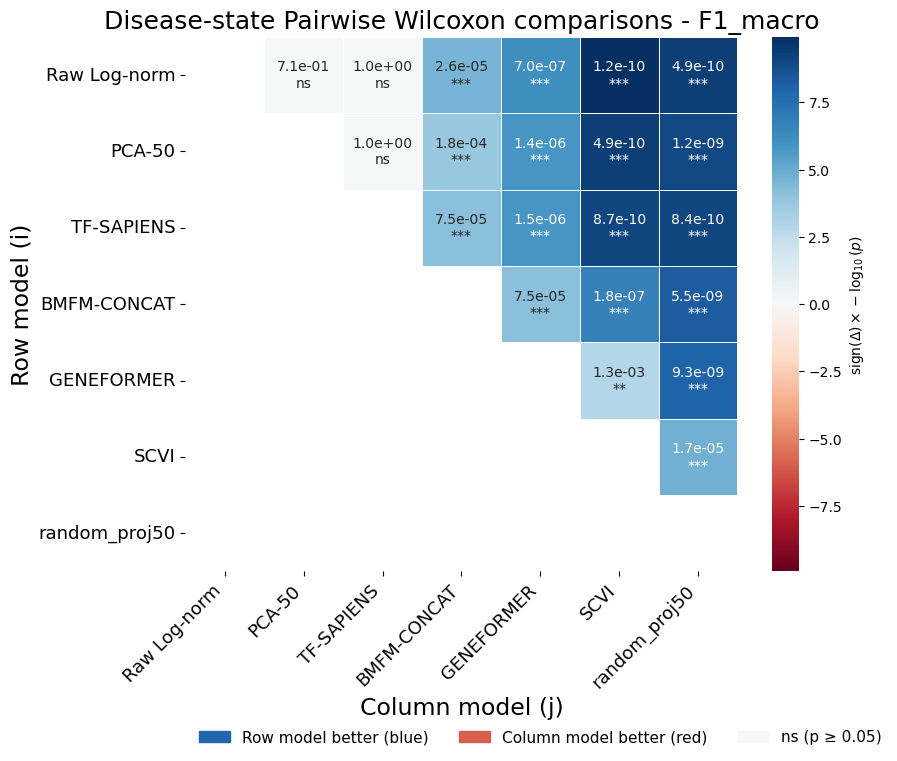

In [33]:
disease_results = friedman_analysis(
    df=df,
    task_col='task_id',
    dataset_col='dataset_id',      # <-- ADD THIS: collapses 868 tasks to ~82 datasets
    feature_col='feature_clean',
    metric='F1_macro',
    exclude_features=[],
    alpha=0.05,
    color_map=palette_dict,
    title='Critical Difference Diagram — Disease Prediction (Standard Mode, dataset-corrected)',
    figsize=(9, 3),
)

print('Disease average ranks (dataset-corrected):')
print(disease_results['friedman_results']['avg_ranks'].round(3))
print(f"T = {disease_results['friedman_results']['T']} (datasets, not tasks)")

pairwise_df = pairwise_wilcoxon_holm(
    disease_results["score_matrix"],
    alpha=0.05,
)

fig, ax, score, annot = plot_pairwise_direction_significance_heatmap(
    pairwise_df,
    feature_order=feature_order,
    metric="F1_macro",
    title_prefix= 'Disease-state',
)

In [34]:
fig.savefig("./plots_brief/test_files_standard_disease_27_05_final_F1_friW.png", dpi=300, bbox_inches="tight")

In [35]:
import importlib
import friedman_ranking
importlib.reload(friedman_ranking)

from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)

In [36]:
import importlib
import evaluation
importlib.reload(evaluation)

from evaluation import ( plot_overall_performance_bar)

Datasets before dropna: 82, after: 82 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (82, 7)  (T=82 datasets, M=7 models)

=== Friedman Test ===
T=82 tasks, M=7 models
Chi² = 235.2596, p = 5.7732e-48
Iman-Davenport F = 74.2229, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
Raw Log-norm     2.2683
PCA-50           2.7561
TF-SAPIENS       2.7683
BMFM-CONCAT      3.8171
GENEFORMER       4.8049
SCVI             5.4634
random_proj50    6.1220
Nemenyi CD (alpha=0.05, M=7, T=82): 0.9949

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_minus_j  p_raw  p_holm  significant
Raw Log-norm          SCVI                0.1502 0.0000  0.0000         True
Raw Log-norm random_proj50                0.2142 0.0000  0.0000         True
      PCA-50 random_proj50                0.2050 0.0000  0.0000  

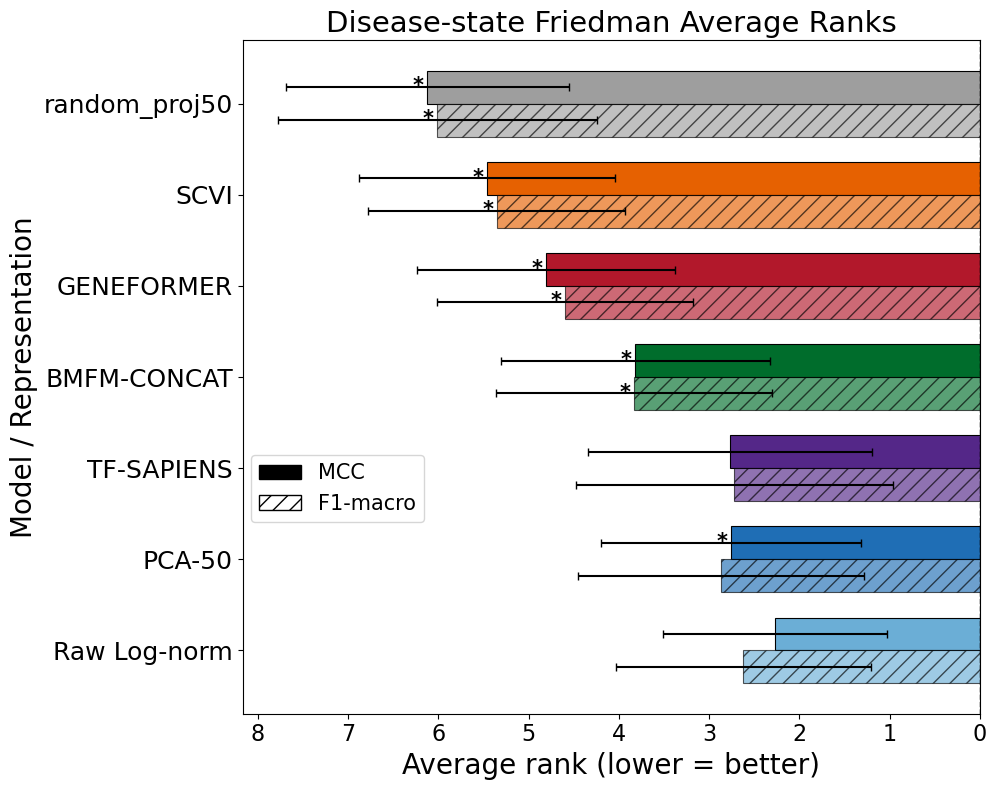

In [37]:
fig, ax, summary = plot_friedman_as_bar(
    df=df,
    plot_overall_performance_bar=plot_overall_performance_bar,
    task_col="task_id",
    dataset_col="dataset_id",   # <-- ADD THIS, matches the friedman_analysis call above
    metrics=("MCC", "F1_macro"),
    exclude_features=[],
    feature_order=feature_order,
    color_map=palette_dict,
    figsize=(10, 8),
    errorbar='std',
    title_prefix= 'Disease-state',
    save_path="./plots_brief/test_files_standard_disease_27_05_final_mccF1_fri_std_str.png",
)

# pseudobulk Mode Results 27/05
22 09

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

### start

In [20]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_pseudobulk_disease_27_05_results"

v1 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_disease_27_05.parquet"))
v1


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,pooling,balanced_acc,MCC,...,recall_macro_donor,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,AUROC_ovr,proba_unavailable,error,metric_error
0,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033,median,0.666667,0.327327,...,0.666667,0.666667,0.0,0.487950,15.0,raw_lognorm,NaN,None,None,None
1,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033,median,0.750000,0.490990,...,0.750000,0.733333,0.0,0.457738,15.0,raw_pca50,NaN,None,None,None
2,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033,median,0.666667,0.327327,...,0.666667,0.666667,0.0,0.487950,15.0,random_proj50,NaN,None,None,None
3,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033,median,0.750000,0.490990,...,0.750000,0.733333,0.0,0.457738,15.0,obsm[scvi],NaN,None,None,None
4,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033,median,0.666667,0.327327,...,0.666667,0.666667,0.0,0.487950,15.0,obsm[geneformer],NaN,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32484,fold_3,9.0,4.0,None,3966ba97-beb8-4d0b-9954-d3775cd2cd61,placental villous trophoblast,31931,median,NaN,NaN,...,0.375000,0.750000,0.0,0.500000,4.0,random_proj50,NaN,None,None,single_class_after_filtering
32485,fold_3,9.0,4.0,None,3966ba97-beb8-4d0b-9954-d3775cd2cd61,placental villous trophoblast,31931,median,NaN,NaN,...,0.375000,0.750000,0.0,0.500000,4.0,obsm[scvi],NaN,None,None,single_class_after_filtering
32486,fold_3,9.0,4.0,None,3966ba97-beb8-4d0b-9954-d3775cd2cd61,placental villous trophoblast,31931,median,NaN,NaN,...,1.000000,1.000000,1.0,0.000000,4.0,obsm[geneformer],NaN,None,None,single_class_after_filtering
32487,fold_3,9.0,4.0,None,3966ba97-beb8-4d0b-9954-d3775cd2cd61,placental villous trophoblast,31931,median,NaN,NaN,...,0.375000,0.750000,0.0,0.500000,4.0,obsm[tf-sapiens],NaN,None,None,single_class_after_filtering


In [21]:
pd.crosstab(v1.dataset_id, v1.feature)

feature,obsm[bmfm],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55,55,55,55,55,55,55,55
07760522-707a-4a1c-8891-dbd1226d6b27,0,4,4,4,4,4,4,4
0b75c598-0893-4216-afe8-5414cab7739d,27,27,27,27,27,27,27,27
0bc7235a-ae5a-479d-a487-510435377e55,30,30,30,30,30,30,30,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29,29,29,29,29,29,29,29
...,...,...,...,...,...,...,...,...
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115,115,115,115,115,115,115,115
f1606894-59df-4794-a37f-baa7c6fb6de1,55,55,55,55,55,55,55,55
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,0,4,4,4,4,4,4,4


In [22]:

v2 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_disease_27_05_v2.parquet"))
v2


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,pooling,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,AUROC_ovr,proba_unavailable,skip_reason,metric_error,error
0,fold_1,156.0,39.0,None,9dbab10c-118d-496b-966a-67f1763a6b7d,B cell,25861.0,median,0.794118,0.393445,...,0.641026,0.0,0.485971,39.0,obsm[bmfm_var1],NaN,None,None,None,None
1,fold_2,156.0,39.0,None,9dbab10c-118d-496b-966a-67f1763a6b7d,B cell,25861.0,median,0.882353,0.542326,...,0.794872,0.0,0.409074,39.0,obsm[bmfm_var1],NaN,None,None,None,None
2,fold_3,156.0,39.0,None,9dbab10c-118d-496b-966a-67f1763a6b7d,B cell,25861.0,median,0.552941,0.076696,...,0.666667,0.0,0.477567,39.0,obsm[bmfm_var1],NaN,None,None,None,None
3,fold_4,156.0,39.0,None,9dbab10c-118d-496b-966a-67f1763a6b7d,B cell,25861.0,median,0.782353,0.409048,...,0.769231,0.0,0.426833,39.0,obsm[bmfm_var1],NaN,None,None,None,None
4,fold_5,156.0,39.0,None,9dbab10c-118d-496b-966a-67f1763a6b7d,B cell,25861.0,median,0.867647,0.512450,...,0.769231,0.0,0.426833,39.0,obsm[bmfm_var1],NaN,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3906,fold_1,70.0,18.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,cerebral cortex endothelial cell,27816.0,median,0.600000,0.203859,...,0.611111,0.0,0.501631,18.0,obsm[bmfm_var1],NaN,None,None,None,None
3907,fold_2,70.0,18.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,cerebral cortex endothelial cell,27816.0,median,0.541667,0.087706,...,0.611111,0.0,0.501631,18.0,obsm[bmfm_var1],NaN,None,None,None,None
3908,fold_3,70.0,18.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,cerebral cortex endothelial cell,27816.0,median,0.694805,0.402911,...,0.722222,0.0,0.460889,18.0,obsm[bmfm_var1],NaN,None,None,None,None
3909,fold_4,71.0,17.0,None,c2876b1b-06d8-4d96-a56b-5304f815b99a,cerebral cortex endothelial cell,27816.0,median,0.659722,0.349934,...,0.647059,0.0,0.492592,17.0,obsm[bmfm_var1],NaN,None,None,None,None


In [23]:
pd.crosstab(v2.dataset_id, v2.feature)

feature,obsm[bmfm_var1]
dataset_id,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55
0b75c598-0893-4216-afe8-5414cab7739d,27
0bc7235a-ae5a-479d-a487-510435377e55,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29
19e46756-9100-4e01-8b0e-23b557558a4c,35
...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,115
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,75
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115


In [24]:

v3 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_disease_27_05_v3.parquet"))
v3


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,pooling,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,proba_unavailable,AUROC_ovr,error,skip_reason
0,fold_1,14.0,8.0,None,99950e99-2758-41d2-b2c9-643edcdf6d82,"naive thymus-derived CD4-positive, alpha-beta ...",17991.0,median,0.928571,0.654654,...,0.875000,0.0,0.353553,8.0,obsm[bmfm_WCED10],None,None,NaN,None,None
1,fold_1,14.0,8.0,None,99950e99-2758-41d2-b2c9-643edcdf6d82,"naive thymus-derived CD4-positive, alpha-beta ...",17991.0,median,0.500000,0.000000,...,0.875000,0.0,0.353553,8.0,obsm[bmfm_MLMMUL],None,None,NaN,None,None
2,fold_2,15.0,7.0,None,99950e99-2758-41d2-b2c9-643edcdf6d82,"naive thymus-derived CD4-positive, alpha-beta ...",17991.0,median,0.666667,0.258199,...,0.428571,0.0,0.534522,7.0,obsm[bmfm_WCED10],None,None,NaN,None,None
3,fold_2,15.0,7.0,None,99950e99-2758-41d2-b2c9-643edcdf6d82,"naive thymus-derived CD4-positive, alpha-beta ...",17991.0,median,0.666667,0.258199,...,0.428571,0.0,0.534522,7.0,obsm[bmfm_MLMMUL],None,None,NaN,None,None
4,fold_3,15.0,7.0,None,99950e99-2758-41d2-b2c9-643edcdf6d82,"naive thymus-derived CD4-positive, alpha-beta ...",17991.0,median,0.000000,-1.000000,...,0.000000,0.0,0.000000,7.0,obsm[bmfm_WCED10],None,None,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7765,fold_4,38.0,12.0,None,7b20c613-9add-43d1-87e9-defd3d9b9f8c,fibroblast,17514.0,median,0.866667,0.772470,...,0.833333,0.0,0.389249,12.0,obsm[bmfm_WCED10],None,None,0.971633,None,None
7766,fold_4,38.0,12.0,None,7b20c613-9add-43d1-87e9-defd3d9b9f8c,fibroblast,17514.0,median,0.600000,0.410328,...,0.583333,0.0,0.514929,12.0,obsm[bmfm_MLMMUL],None,True,NaN,None,None
7767,None,NaN,NaN,None,7bb64315-9e5a-41b9-9235-59acf9642a3e,CD4-positive helper T cell,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,None,NaN,None,all_folds_degenerate
7768,None,NaN,NaN,None,7bb64315-9e5a-41b9-9235-59acf9642a3e,unknown,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,None,NaN,None,all_folds_degenerate


In [25]:
pd.crosstab(v3.dataset_id, v3.feature)

feature,obsm[bmfm_MLMMUL],obsm[bmfm_WCED10]
dataset_id,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55,55
0b75c598-0893-4216-afe8-5414cab7739d,27,27
0bc7235a-ae5a-479d-a487-510435377e55,30,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29,29
19e46756-9100-4e01-8b0e-23b557558a4c,35,35
...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,115,115
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,75,75
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115,115


In [27]:

v9 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_disease_27_05_9.parquet"))
v9


,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,pooling,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,AUROC_ovr,feature,metric_error,AUROC,AUPRC,error
0,fold_1,38.0,20.0,None,6a270451-b4d9-43e0-aa89-e33aac1ac74b,T cell,24836,median,0.263889,0.199002,...,0.350000,0.0,0.489360,20.0,NaN,obsm[bmfm],None,NaN,NaN,None
1,fold_1,38.0,20.0,None,6a270451-b4d9-43e0-aa89-e33aac1ac74b,T cell,24836,median,0.388889,0.338015,...,0.450000,0.0,0.510418,20.0,0.649049,obsm[bmfm_WCED10],None,NaN,NaN,None
2,fold_1,38.0,20.0,None,6a270451-b4d9-43e0-aa89-e33aac1ac74b,T cell,24836,median,0.384259,0.320690,...,0.500000,0.0,0.512989,20.0,NaN,obsm[bmfm_MLMMUL],None,NaN,NaN,None
3,fold_1,38.0,20.0,None,6a270451-b4d9-43e0-aa89-e33aac1ac74b,T cell,24836,median,0.490741,0.463943,...,0.550000,0.0,0.510418,20.0,0.748357,obsm[bmfm_var1],None,NaN,NaN,None
4,fold_2,39.0,19.0,None,6a270451-b4d9-43e0-aa89-e33aac1ac74b,T cell,24836,median,0.488889,0.364447,...,0.526316,0.0,0.512989,19.0,0.688337,obsm[bmfm],None,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,fold_3,7.0,3.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,median,0.500000,0.000000,...,0.666667,0.0,0.577350,3.0,NaN,obsm[bmfm_var1],None,0.5,0.666667,None
920,fold_4,8.0,2.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,median,NaN,NaN,...,0.000000,0.0,0.000000,2.0,NaN,obsm[bmfm],single_class_after_filtering,NaN,NaN,None
921,fold_4,8.0,2.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,median,NaN,NaN,...,0.000000,0.0,0.000000,2.0,NaN,obsm[bmfm_WCED10],single_class_after_filtering,NaN,NaN,None
922,fold_4,8.0,2.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451,median,NaN,NaN,...,0.000000,0.0,0.000000,2.0,NaN,obsm[bmfm_MLMMUL],single_class_after_filtering,NaN,NaN,None


In [28]:
pd.crosstab(v9.dataset_id, v9.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1]
dataset_id,,,,
07760522-707a-4a1c-8891-dbd1226d6b27,4,4,4,4
13b61a7d-5605-4948-ba48-02c588960143,10,10,10,10
251b1a7e-d050-4486-8d50-4c2619eb0f46,4,4,4,4
2856d06c-0ff9-4e01-bfc9-202b74d0b60f,4,4,4,4
3966ba97-beb8-4d0b-9954-d3775cd2cd61,7,7,7,7
4dd1cd23-fc4d-4fd1-9709-602540f3ca6f,4,4,4,4
576f193c-75d0-4a11-bd25-8676587e6dc2,29,29,29,29
5829c7ba-697f-418e-8b98-d605b192dc48,4,4,4,4
6a270451-b4d9-43e0-aa89-e33aac1ac74b,21,21,21,21


In [29]:

df = pd.concat([v1, v2 ,v3, v9], ignore_index=True)
df

,fold,n_train,n_test,n_per_class,dataset_id,cell_type,n_genes,pooling,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,AUROC_ovr,proba_unavailable,error,metric_error,skip_reason
0,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033.0,median,0.666667,0.327327,...,0.666667,0.0,0.487950,15.0,raw_lognorm,NaN,None,None,None,NaN
1,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033.0,median,0.750000,0.490990,...,0.733333,0.0,0.457738,15.0,raw_pca50,NaN,None,None,None,NaN
2,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033.0,median,0.666667,0.327327,...,0.666667,0.0,0.487950,15.0,random_proj50,NaN,None,None,None,NaN
3,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033.0,median,0.750000,0.490990,...,0.733333,0.0,0.457738,15.0,obsm[scvi],NaN,None,None,None,NaN
4,fold_1,57.0,15.0,None,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,dendritic cell,22033.0,median,0.666667,0.327327,...,0.666667,0.0,0.487950,15.0,obsm[geneformer],NaN,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45089,fold_3,7.0,3.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451.0,median,0.500000,0.000000,...,0.666667,0.0,0.577350,3.0,obsm[bmfm_var1],NaN,None,None,None,NaN
45090,fold_4,8.0,2.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451.0,median,NaN,NaN,...,0.000000,0.0,0.000000,2.0,obsm[bmfm],NaN,None,None,single_class_after_filtering,NaN
45091,fold_4,8.0,2.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451.0,median,NaN,NaN,...,0.000000,0.0,0.000000,2.0,obsm[bmfm_WCED10],NaN,None,None,single_class_after_filtering,NaN
45092,fold_4,8.0,2.0,None,5829c7ba-697f-418e-8b98-d605b192dc48,oligodendrocyte,30451.0,median,NaN,NaN,...,0.000000,0.0,0.000000,2.0,obsm[bmfm_MLMMUL],NaN,None,None,single_class_after_filtering,NaN


In [30]:
pd.crosstab(df.dataset_id, df.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,55,55,55,55,55,55,55,55,55,55,55
07760522-707a-4a1c-8891-dbd1226d6b27,4,4,4,4,4,4,4,4,4,4,4
0b75c598-0893-4216-afe8-5414cab7739d,27,27,27,27,27,27,27,27,27,27,27
0bc7235a-ae5a-479d-a487-510435377e55,30,30,30,30,30,30,30,30,30,30,30
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,29,29,29,29,29,29,29,29,29,29,29
...,...,...,...,...,...,...,...,...,...,...,...
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,115,115,115,115,115,115,115,115,115,115,115
f1606894-59df-4794-a37f-baa7c6fb6de1,55,55,55,55,55,55,55,55,55,55,55
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,4,4,4,4,4,4,4,4,4,4,4


In [31]:
df.to_parquet("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_pseudobulk_disease_27_05_results/test_files_pseudobulk_disease_27_05_final.parquet")

## 2. Load and Prepare Results

In [3]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_pseudobulk_disease_27_05_results/test_files_pseudobulk_disease_27_05_final.parquet"
df = load_and_prepare_results(parquet_path)

print(f"After filtering (errors/skips removed):")
print(f"  Total rows: {len(df):,}")
print(f"  Unique tasks: {df['task_id'].nunique()}")
print(f"  Features: {sorted(df['feature_clean'].unique())}")
print(f"\nSample:")
df[['task_id', 'fold', 'feature_clean', 'MCC', 'balanced_acc', 'F1_macro']].head(9)

After filtering (errors/skips removed):
  Total rows: 44,902
  Unique tasks: 868
  Features: ['BMFM-CONCAT', 'BMFM_BW', 'BMFM_LM', 'BMFM_LW', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-EXEMPLAR-HUMAN', 'TF-SAPIENS', 'random_proj50']

Sample:


,task_id,fold,feature_clean,MCC,balanced_acc,F1_macro
0,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,Raw Log-norm,0.327327,0.666667,0.660633
1,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,PCA-50,0.490990,0.750000,0.732143
2,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,random_proj50,0.327327,0.666667,0.660633
3,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,SCVI,0.490990,0.750000,0.732143
4,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,GENEFORMER,0.327327,0.666667,0.660633
5,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,TF-SAPIENS,0.388889,0.694444,0.666667
6,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,TF-EXEMPLAR-HUMAN,0.577350,0.777778,0.732143
7,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_1,BMFM_LW,0.490990,0.750000,0.732143
8,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::dendriti...,fold_2,Raw Log-norm,0.258199,0.625000,0.625668


In [4]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM-CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [5]:
df= df.query('feature_clean.isin(@feature_order)')

In [6]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

## rank-based Demšar-style

### freidman corrected 20 08

In [7]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar)

Datasets before dropna: 82, after: 82 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (82, 7)  (T=82 datasets, M=7 models)

=== Friedman Test ===
T=82 tasks, M=7 models
Chi² = 38.7662, p = 7.9539e-07
Iman-Davenport F = 6.9281, p = 4.4550e-07
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
TF-SAPIENS       3.1829
BMFM-CONCAT      3.4573
PCA-50           3.5427
GENEFORMER       4.1646
Raw Log-norm     4.3171
random_proj50    4.6220
SCVI             4.7134
Nemenyi CD (alpha=0.05, M=7, T=82): 0.9949
Disease average ranks (dataset-corrected):
feature_clean
TF-SAPIENS       3.183
BMFM-CONCAT      3.457
PCA-50           3.543
GENEFORMER       4.165
Raw Log-norm     4.317
random_proj50    4.622
SCVI             4.713
dtype: float64
T = 82 (datasets, not tasks)

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_del

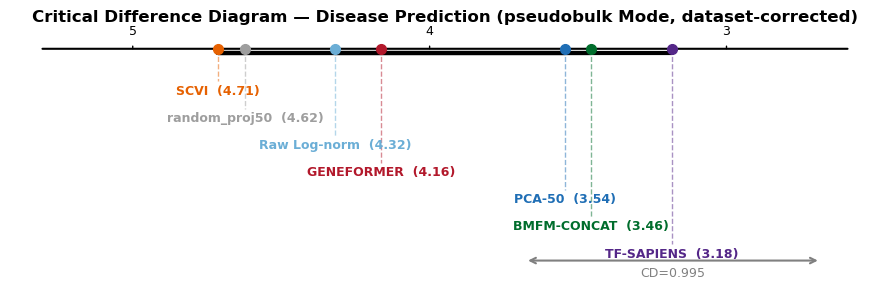

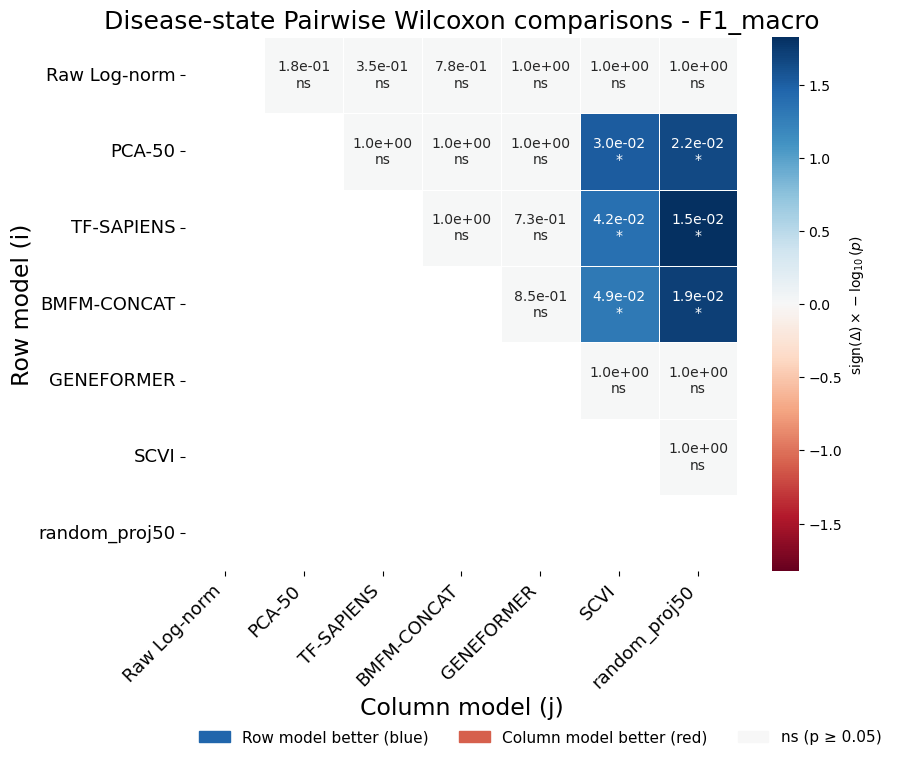

In [8]:
disease_results = friedman_analysis(
    df=df,
    task_col='task_id',
    dataset_col='dataset_id',      # <-- ADD THIS: collapses 868 tasks to ~82 datasets
    feature_col='feature_clean',
    metric='F1_macro',
    exclude_features=[],
    alpha=0.05,
    color_map=palette_dict,
    title='Critical Difference Diagram — Disease Prediction (pseudobulk Mode, dataset-corrected)',
    figsize=(9, 3),
)

print('Disease average ranks (dataset-corrected):')
print(disease_results['friedman_results']['avg_ranks'].round(3))
print(f"T = {disease_results['friedman_results']['T']} (datasets, not tasks)")

pairwise_df = pairwise_wilcoxon_holm(
    disease_results["score_matrix"],
    alpha=0.05,
)

fig, ax, score, annot = plot_pairwise_direction_significance_heatmap(
    pairwise_df,
    feature_order=feature_order,
    metric="F1_macro",
    title_prefix= 'Disease-state',
)

In [9]:
fig.savefig("./plots_brief/test_files_pseudobulk_disease_27_05_final_F1_friW.png", dpi=300, bbox_inches="tight")

In [25]:
import importlib
import friedman_ranking
importlib.reload(friedman_ranking)

from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)

In [26]:
import importlib
import evaluation
importlib.reload(evaluation)

from evaluation import ( plot_overall_performance_bar)

Datasets before dropna: 82, after: 82 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (82, 7)  (T=82 datasets, M=7 models)

=== Friedman Test ===
T=82 tasks, M=7 models
Chi² = 57.7977, p = 1.2594e-10
Iman-Davenport F = 10.7821, p = 2.8432e-11
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
TF-SAPIENS       3.1890
BMFM-CONCAT      3.2256
PCA-50           3.5000
Raw Log-norm     4.0183
GENEFORMER       4.2500
SCVI             4.7744
random_proj50    5.0427
Nemenyi CD (alpha=0.05, M=7, T=82): 0.9949

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_minus_j  p_raw  p_holm  significant
  TF-SAPIENS random_proj50                0.0622 0.0000  0.0010         True
 BMFM-CONCAT random_proj50                0.0577 0.0001  0.0015         True
      PCA-50 random_proj50                0.0481 0.0001  0.0020   

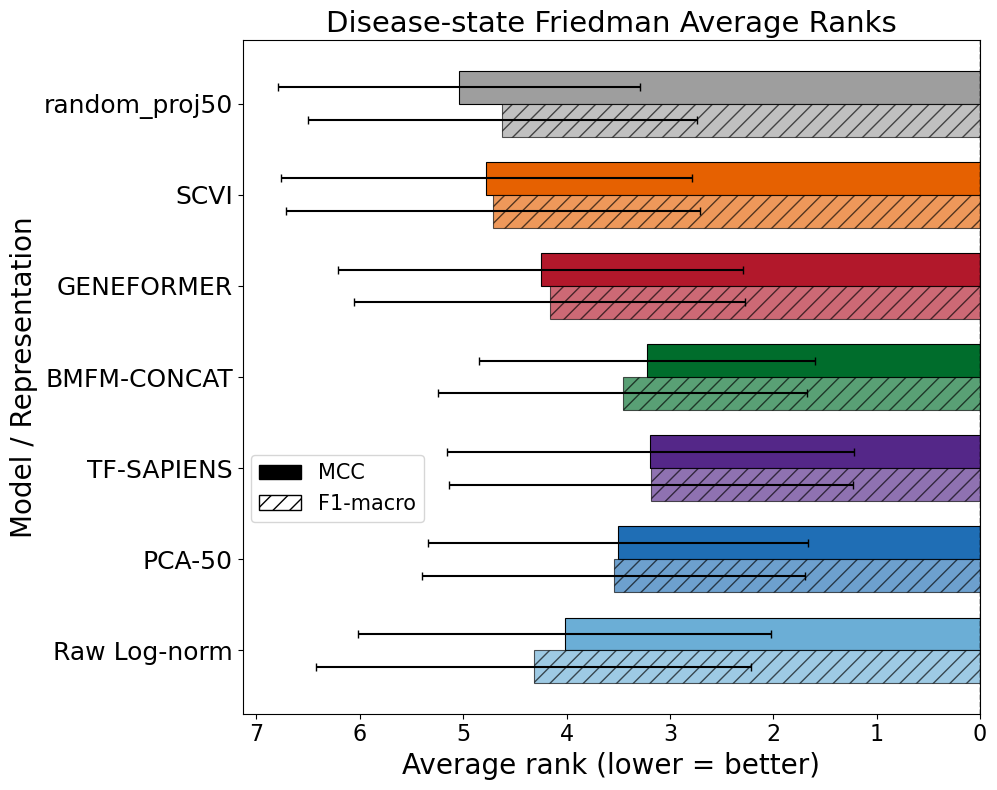

In [27]:
fig, ax, summary = plot_friedman_as_bar(
    df=df,
    plot_overall_performance_bar=plot_overall_performance_bar,
    task_col="task_id",
    dataset_col="dataset_id",   # <-- ADD THIS
    metrics=("MCC", "F1_macro"),
    exclude_features=[],
    feature_order=feature_order,
    color_map=palette_dict,
    figsize=(10, 8),
    errorbar='std',
    title_prefix= 'Disease-state',
    save_path="./plots_brief/test_files_pseudobulk_disease_27_05_final_mccF1_fri_std.png",
)

# Low data Mode Results 27/05
22 09

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

### start

In [2]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_disease_27_05_results"

v1 = pd.read_parquet(os.path.join(dir_path, "test_files_low_disease_27_05.parquet"))
v1


,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,cell_type,n_genes,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,proba_unavailable,AUROC_ovr,error,donor_metric_error
0,fold_1,4.0,231.0,2.0,0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.497685,-0.017376,...,0.664319,0.000000,0.575328,3.0,raw_lognorm,None,None,NaN,None,None
1,fold_1,4.0,231.0,2.0,0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.500000,0.000000,...,0.333333,0.000000,0.577350,3.0,raw_pca50,None,None,NaN,None,None
2,fold_1,4.0,231.0,2.0,0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.603704,0.114755,...,0.638997,0.466667,0.157233,3.0,random_proj50,None,None,NaN,None,None
3,fold_1,4.0,231.0,2.0,0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.674537,0.175092,...,0.658034,0.605634,0.066859,3.0,obsm[scvi],None,None,NaN,None,None
4,fold_1,4.0,231.0,2.0,0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927,0.585185,0.087498,...,0.510544,0.351351,0.251093,3.0,obsm[geneformer],None,None,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624445,fold_5,1997.0,2396.0,1024.0,4,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529,0.472626,-0.047622,...,0.544086,0.199377,0.282702,9.0,obsm[scvi],None,None,NaN,None,None
1624446,fold_5,1997.0,2396.0,1024.0,4,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529,0.494105,-0.010509,...,0.516903,0.105263,0.272776,9.0,obsm[geneformer],None,None,NaN,None,None
1624447,fold_5,1997.0,2396.0,1024.0,4,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529,0.690951,0.350489,...,0.661937,0.210526,0.244857,9.0,obsm[tf-sapiens],None,None,NaN,None,None
1624448,fold_5,1997.0,2396.0,1024.0,4,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529,0.596284,0.181379,...,0.626845,0.000000,0.308344,9.0,obsm[tf-exemplar-human],None,None,NaN,None,None


In [3]:
pd.crosstab(v1.dataset_id, v1.feature)

feature,obsm[bmfm],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,2750,2750,2750,2750,2750,2750,2750,2750
07760522-707a-4a1c-8891-dbd1226d6b27,0,200,200,200,200,200,200,200
0b75c598-0893-4216-afe8-5414cab7739d,1350,1350,1350,1350,1350,1350,1350,1350
0bc7235a-ae5a-479d-a487-510435377e55,1500,1500,1500,1500,1500,1500,1500,1500
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,1450,1450,1450,1450,1450,1450,1450,1450
...,...,...,...,...,...,...,...,...
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5750,5750,5750,5750,5750,5750,5750,5750
f1606894-59df-4794-a37f-baa7c6fb6de1,2750,2750,2750,2750,2750,2750,2750,2750
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,0,200,200,200,200,200,200,200


In [4]:

v2 = pd.read_parquet(os.path.join(dir_path, "test_files_low_disease_27_05_v2.parquet"))
v2 = v2.query('feature.isin(["obsm[bmfm_var1]"])')
v2


,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,cell_type,n_genes,balanced_acc,MCC,...,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,skip_reason,proba_unavailable,AUROC_ovr,error,donor_metric_error
0,fold_1,4.0,257.0,2.0,0.0,3c75a463-6a87-4132-83a8-c3002624394d,"activated CD8-positive, alpha-beta T cell",16896.0,0.401411,-0.134728,...,0.264706,0.236191,3.0,obsm[bmfm_var1],None,None,None,NaN,None,None
1,fold_2,4.0,1327.0,2.0,0.0,3c75a463-6a87-4132-83a8-c3002624394d,"activated CD8-positive, alpha-beta T cell",16896.0,0.587860,0.158141,...,0.238255,0.283022,4.0,obsm[bmfm_var1],None,None,None,NaN,None,None
2,fold_3,4.0,481.0,2.0,0.0,3c75a463-6a87-4132-83a8-c3002624394d,"activated CD8-positive, alpha-beta T cell",16896.0,0.630355,0.267987,...,0.478102,0.175605,3.0,obsm[bmfm_var1],None,None,None,NaN,None,None
3,fold_4,4.0,1451.0,2.0,0.0,3c75a463-6a87-4132-83a8-c3002624394d,"activated CD8-positive, alpha-beta T cell",16896.0,0.442698,-0.097478,...,0.229508,0.179160,4.0,obsm[bmfm_var1],None,None,None,NaN,None,None
4,fold_5,4.0,1335.0,2.0,0.0,3c75a463-6a87-4132-83a8-c3002624394d,"activated CD8-positive, alpha-beta T cell",16896.0,0.558908,0.115247,...,0.033670,0.393695,4.0,obsm[bmfm_var1],None,None,None,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236496,fold_1,2048.0,8139.0,1024.0,4.0,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529.0,0.417728,-0.039939,...,0.228744,0.218897,6.0,obsm[bmfm_var1],None,None,None,NaN,None,None
236497,fold_2,2048.0,8133.0,1024.0,4.0,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529.0,NaN,NaN,...,0.018803,0.398663,8.0,obsm[bmfm_var1],single_class_after_filtering,None,None,NaN,None,None
236498,fold_3,1844.0,6651.0,1024.0,4.0,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529.0,0.579932,0.100080,...,0.473297,0.070824,10.0,obsm[bmfm_var1],None,None,None,NaN,None,None
236499,fold_4,2048.0,4284.0,1024.0,4.0,a37f857c-779f-464e-9310-3db43a1811e7,macrophage,20529.0,0.464216,-0.030898,...,0.259259,0.160847,8.0,obsm[bmfm_var1],None,None,None,NaN,None,None


In [5]:
pd.crosstab(v2.dataset_id, v2.feature)

feature,obsm[bmfm_var1]
dataset_id,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,2750
0b75c598-0893-4216-afe8-5414cab7739d,1350
0bc7235a-ae5a-479d-a487-510435377e55,1500
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,1450
19e46756-9100-4e01-8b0e-23b557558a4c,1750
...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5750
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,3750
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5750


In [6]:

v3 = pd.read_parquet(os.path.join(dir_path, "test_files_low_disease_27_05_v3.parquet"))
v3 = v3.query('feature.isin(["obsm[bmfm_MLMMUL]","obsm[bmfm_WCED10]"])')
v3

,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,cell_type,n_genes,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,proba_unavailable,AUROC_ovr,donor_metric_error,error
3,fold_1,4.0,89.0,2.0,0,fe4b89d5-461e-440c-a5a8-621b37b122c0,type L enteroendocrine cell,17667,0.361331,-0.253008,...,0.471278,0.214286,0.313225,5.0,obsm[bmfm_WCED10],None,None,NaN,None,None
4,fold_1,4.0,89.0,2.0,0,fe4b89d5-461e-440c-a5a8-621b37b122c0,type L enteroendocrine cell,17667,0.599473,0.221554,...,0.666090,0.035714,0.432641,5.0,obsm[bmfm_MLMMUL],None,None,NaN,None,None
8,fold_2,4.0,82.0,2.0,0,fe4b89d5-461e-440c-a5a8-621b37b122c0,type L enteroendocrine cell,17667,0.515805,0.028980,...,0.499070,0.250000,0.168524,7.0,obsm[bmfm_WCED10],None,None,NaN,None,None
9,fold_2,4.0,82.0,2.0,0,fe4b89d5-461e-440c-a5a8-621b37b122c0,type L enteroendocrine cell,17667,0.326149,-0.336638,...,0.416397,0.000000,0.328585,7.0,obsm[bmfm_MLMMUL],None,None,NaN,None,None
13,fold_3,4.0,570.0,2.0,0,fe4b89d5-461e-440c-a5a8-621b37b122c0,type L enteroendocrine cell,17667,0.544988,0.082943,...,0.483493,0.000000,0.423752,9.0,obsm[bmfm_WCED10],None,None,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953639,fold_3,4096.0,1389.0,1024.0,4,d9f3a82c-24bb-4277-b715-8ec92a33dd32,monocyte,20948,0.263750,0.135492,...,0.344579,0.105263,0.165392,11.0,obsm[bmfm_MLMMUL],None,True,NaN,None,None
953643,fold_4,4096.0,2608.0,1024.0,4,d9f3a82c-24bb-4277-b715-8ec92a33dd32,monocyte,20948,0.231193,0.041138,...,0.341899,0.000000,0.228793,32.0,obsm[bmfm_WCED10],None,True,NaN,None,None
953644,fold_4,4096.0,2608.0,1024.0,4,d9f3a82c-24bb-4277-b715-8ec92a33dd32,monocyte,20948,0.161533,0.036600,...,0.369017,0.000000,0.271389,32.0,obsm[bmfm_MLMMUL],None,True,NaN,None,None
953648,fold_5,4096.0,5025.0,1024.0,4,d9f3a82c-24bb-4277-b715-8ec92a33dd32,monocyte,20948,0.205566,-0.072061,...,0.482526,0.050000,0.233742,30.0,obsm[bmfm_WCED10],None,True,NaN,None,None


In [7]:
pd.crosstab(v3.dataset_id, v3.feature)

feature,obsm[bmfm_MLMMUL],obsm[bmfm_WCED10]
dataset_id,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,2750,2750
0b75c598-0893-4216-afe8-5414cab7739d,1350,1350
0bc7235a-ae5a-479d-a487-510435377e55,1500,1500
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,1450,1450
19e46756-9100-4e01-8b0e-23b557558a4c,1750,1750
...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5750,5750
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,3750,3750
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5750,5750


In [8]:

v9= pd.read_parquet(os.path.join(dir_path, "test_files_low_disease_27_05_9.parquet"))
v9


,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,cell_type,n_genes,balanced_acc,MCC,...,recall_macro_donor,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,metric_error,feature,AUROC_ovr,proba_unavailable,error
0,fold_1,4.0,12751.0,2.0,0,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.526415,0.070882,...,0.500000,0.526415,0.163002,0.513944,2.0,None,obsm[bmfm],NaN,None,None
1,fold_1,4.0,12751.0,2.0,0,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.551717,0.185394,...,0.500000,0.551717,0.141014,0.580821,2.0,None,obsm[bmfm_WCED10],NaN,None,None
2,fold_1,4.0,12751.0,2.0,0,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.414432,-0.151542,...,0.000000,0.414432,0.364409,0.070742,2.0,None,obsm[bmfm_MLMMUL],NaN,None,None
3,fold_1,4.0,12751.0,2.0,0,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,0.479331,-0.042266,...,0.500000,0.479331,0.219584,0.367339,2.0,None,obsm[bmfm_var1],NaN,None,None
4,fold_2,4.0,19941.0,2.0,0,251b1a7e-d050-4486-8d50-4c2619eb0f46,neuron,31708,NaN,NaN,...,1.000000,0.733199,0.528830,0.289022,2.0,single_class_after_filtering,obsm[bmfm],NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46195,fold_4,3115.0,2053.0,1024.0,4,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887,0.872310,0.619573,...,1.000000,0.780826,0.645833,0.100433,4.0,None,obsm[bmfm_var1],NaN,True,None
46196,fold_5,3072.0,4303.0,1024.0,4,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887,0.776868,0.612526,...,0.666667,0.416062,0.000000,0.414825,11.0,None,obsm[bmfm],NaN,True,None
46197,fold_5,3072.0,4303.0,1024.0,4,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887,0.828505,0.687728,...,0.666667,0.395597,0.000000,0.410859,11.0,None,obsm[bmfm_WCED10],NaN,True,None
46198,fold_5,3072.0,4303.0,1024.0,4,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887,0.860878,0.821367,...,0.666667,0.448526,0.000000,0.446684,11.0,None,obsm[bmfm_MLMMUL],NaN,True,None


In [9]:
pd.crosstab(v9.dataset_id, v9.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1]
dataset_id,,,,
07760522-707a-4a1c-8891-dbd1226d6b27,200,200,200,200
13b61a7d-5605-4948-ba48-02c588960143,500,500,500,500
251b1a7e-d050-4486-8d50-4c2619eb0f46,200,200,200,200
2856d06c-0ff9-4e01-bfc9-202b74d0b60f,200,200,200,200
3966ba97-beb8-4d0b-9954-d3775cd2cd61,350,350,350,350
4dd1cd23-fc4d-4fd1-9709-602540f3ca6f,200,200,200,200
576f193c-75d0-4a11-bd25-8676587e6dc2,1450,1450,1450,1450
5829c7ba-697f-418e-8b98-d605b192dc48,200,200,200,200
6a270451-b4d9-43e0-aa89-e33aac1ac74b,1050,1050,1050,1050


In [ ]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results"

# Get all parquet files
files = glob.glob(os.path.join(dir_path, "*.parquet"))

# Read and concatenate
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df

In [10]:

df = pd.concat([v1, v2 ,v3, v9], ignore_index=True)
df

,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,cell_type,n_genes,balanced_acc,MCC,...,worst_donor_acc,std_donor_acc,n_valid_donors,feature,metric_error,proba_unavailable,AUROC_ovr,error,donor_metric_error,skip_reason
0,fold_1,4.0,231.0,2.0,0.0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.497685,-0.017376,...,0.000000,0.575328,3.0,raw_lognorm,None,None,NaN,None,None,None
1,fold_1,4.0,231.0,2.0,0.0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.500000,0.000000,...,0.000000,0.577350,3.0,raw_pca50,None,None,NaN,None,None,None
2,fold_1,4.0,231.0,2.0,0.0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.603704,0.114755,...,0.466667,0.157233,3.0,random_proj50,None,None,NaN,None,None,None
3,fold_1,4.0,231.0,2.0,0.0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.674537,0.175092,...,0.605634,0.066859,3.0,obsm[scvi],None,None,NaN,None,None,None
4,fold_1,4.0,231.0,2.0,0.0,2727d83a-0af0-443a-bff8-58dc7028289a,endothelial cell,20927.0,0.585185,0.087498,...,0.351351,0.251093,3.0,obsm[geneformer],None,None,NaN,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249495,fold_4,3115.0,2053.0,1024.0,4.0,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887.0,0.872310,0.619573,...,0.645833,0.100433,4.0,obsm[bmfm_var1],None,True,NaN,None,None,None
2249496,fold_5,3072.0,4303.0,1024.0,4.0,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887.0,0.776868,0.612526,...,0.000000,0.414825,11.0,obsm[bmfm],None,True,NaN,None,None,None
2249497,fold_5,3072.0,4303.0,1024.0,4.0,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887.0,0.828505,0.687728,...,0.000000,0.410859,11.0,obsm[bmfm_WCED10],None,True,NaN,None,None,None
2249498,fold_5,3072.0,4303.0,1024.0,4.0,7bb64315-9e5a-41b9-9235-59acf9642a3e,enterocyte,22887.0,0.860878,0.821367,...,0.000000,0.446684,11.0,obsm[bmfm_MLMMUL],None,True,NaN,None,None,None


In [31]:
df.columns

Index(['fold', 'n_train', 'n_test', 'n_per_class', 'bootstrap', 'dataset_id',
       'cell_type', 'n_genes', 'balanced_acc', 'MCC', 'F1_macro',
       'recall_macro', 'n_unknown_labels', 'n_valid_test_samples', 'log_loss',
       'AUROC', 'AUPRC', 'balanced_acc_donor', 'MCC_donor', 'F1_macro_donor',
       'recall_macro_donor', 'mean_donor_acc', 'worst_donor_acc',
       'std_donor_acc', 'n_valid_donors', 'feature', 'metric_error',
       'proba_unavailable', 'AUROC_ovr', 'error', 'donor_metric_error',
       'skip_reason', 'task_id'],
      dtype='object')

In [12]:
df['task_id'] = df['dataset_id']+'::'+df['cell_type']

In [26]:
df.query('task_id=="b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated columnar cell of tracheobronchial tree"').fold.value_counts()

fold
fold_1    550
fold_2    550
fold_3    550
fold_4    550
fold_5    550
Name: count, dtype: int64

In [30]:
df[(df['task_id']=="b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated columnar cell of tracheobronchial tree") & (df['fold']=='fold_1')].metric_error.value_counts(dropna=False)

metric_error
single_class_after_filtering    550
Name: count, dtype: int64

In [45]:
pd.crosstab(df.dataset_id, df.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750
07760522-707a-4a1c-8891-dbd1226d6b27,200,200,200,200,200,200,200,200,200,200,200
0b75c598-0893-4216-afe8-5414cab7739d,1350,1350,1350,1350,1350,1350,1350,1350,1350,1350,1350
0bc7235a-ae5a-479d-a487-510435377e55,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,1450,1450,1450,1450,1450,1450,1450,1450,1450,1450,1450
...,...,...,...,...,...,...,...,...,...,...,...
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5750,5750,5750,5750,5750,5750,5750,5750,5750,5750,5750
f1606894-59df-4794-a37f-baa7c6fb6de1,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750,2750
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,200,200,200,200,200,200,200,200,200,200,200


In [ ]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_disease_27_05_results"

# Get all parquet files
files = glob.glob(os.path.join(dir_path, "*.parquet"))

# Read and concatenate
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df

In [46]:
df.to_parquet("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_disease_27_05_results/test_files_low_disease_27_05_final.parquet")

## 2. Load and Prepare Results

In [3]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_disease_27_05_results/test_files_low_disease_27_05_final1632.parquet"
df = load_and_prepare_results(parquet_path)

print(f"After filtering (errors/skips removed):")
print(f"  Total rows: {len(df):,}")
print(f"  Unique tasks: {df['task_id'].nunique()}")
print(f"  Features: {sorted(df['feature_clean'].unique())}")
print(f"\nSample:")
df[['task_id', 'fold', 'feature_clean', 'MCC', 'balanced_acc', 'F1_macro']].head(7)

After filtering (errors/skips removed):
  Total rows: 2,245,650
  Unique tasks: 868
  Features: ['BMFM-CONCAT', 'BMFM_BW', 'BMFM_LM', 'BMFM_LW', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-EXEMPLAR-HUMAN', 'TF-SAPIENS', 'random_proj50']

Sample:


,task_id,fold,feature_clean,MCC,balanced_acc,F1_macro
0,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,Raw Log-norm,-0.017376,0.497685,0.482063
1,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,PCA-50,0.000000,0.500000,0.060976
2,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,random_proj50,0.114755,0.603704,0.506410
3,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,SCVI,0.175092,0.674537,0.477688
4,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,GENEFORMER,0.087498,0.585185,0.341178
5,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,TF-SAPIENS,0.301616,0.803241,0.507956
6,2727d83a-0af0-443a-bff8-58dc7028289a::endothel...,fold_1,TF-EXEMPLAR-HUMAN,0.258424,0.760648,0.487830


In [4]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM-CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [5]:
df= df.query('feature_clean.isin(@feature_order)')

In [6]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

## 3. Overall Performance

In [7]:
df['fold'] = df['fold'].str.replace('fold_', '').astype(int)


In [8]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results/test_files_standard_disease_27_05_final.parquet"
df_standard = load_and_prepare_results(parquet_path)

df_lowdata=df.copy()

In [9]:
df_standard= df_standard.query('feature_clean.isin(@feature_order)')

In [10]:
import importlib
import evaluation
importlib.reload(evaluation)

from evaluation import  *

Saved: ./plots_brief/test_files_low_disease_27_05_results_lowF1.png


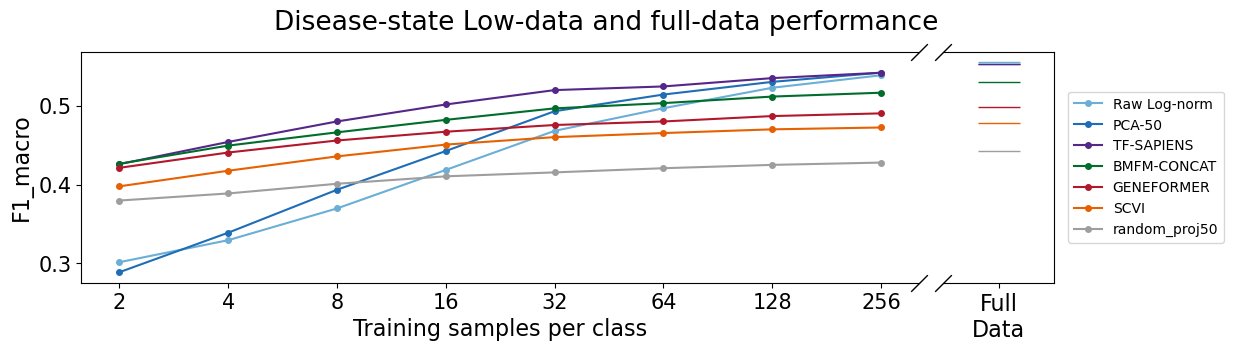

In [11]:
df_lowdata = df_lowdata[~df_lowdata['n_per_class'].isin([1024,512])]

fig = plot_lowdata_with_standard_std(
    df_lowdata=df_lowdata,
    df_standard=df_standard,
    feature_order=feature_order,
    palette_dict=palette_dict,
    metrics=[ "F1_macro"],
    show_error=False,figsize_per_row= (14, 3),
    title_prefix= 'Disease-state',
    save_path="./plots_brief/test_files_low_disease_27_05_results_lowF1.png"

)

plt.show()

### freidman corrected 20 08

In [12]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)

In [13]:
ranks_df_ds, pairwise_df_ds = run_friedman_per_nperclass(
    df_lowdata, df_standard,
    task_col="task_id",
    dataset_col="dataset_id",       # NEW — collapses 82ish datasets, not 864 tasks
    metrics=["MCC", "F1_macro"],
    exclude_features=[],        # unchanged from your call — flagged above, your choice
    alpha=0.05,
)

# Pull out just the number you actually need for the manuscript:
tf_vs_raw = pairwise_df_ds[
    ((pairwise_df_ds["feature_i"] == "TF-SAPIENS") & (pairwise_df_ds["feature_j"] == "Raw Log-norm")) |
    ((pairwise_df_ds["feature_i"] == "Raw Log-norm") & (pairwise_df_ds["feature_j"] == "TF-SAPIENS"))
]
print(tf_vs_raw[["metric", "n_per_class", "mean_delta_i_minus_j", "p_holm", "significant"]]
      .sort_values(["metric", "n_per_class"]))


##################################################
METRIC: MCC

n_per_class = 2.0
Datasets before dropna: 82, after: 82 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (82, 7)  (T=82 datasets, M=7 models)

=== Friedman Test ===
T=82 tasks, M=7 models
Chi² = 171.6847, p = 1.9753e-34
Iman-Davenport F = 43.4149, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
TF-SAPIENS       2.5610
BMFM-CONCAT      2.6829
GENEFORMER       3.1463
SCVI             3.7927
Raw Log-norm     4.8049
random_proj50    5.4390
PCA-50           5.5732

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_minus_j  p_raw  p_holm  significant
 BMFM-CONCAT        PCA-50                0.0831 0.0000  0.0000         True
  TF-SAPIENS random_proj50                0.0889 0.0000  0.0000         True
 BMFM-CONCAT random_proj5

In [29]:
import importlib
import friedman_ranking
importlib.reload(friedman_ranking)

from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)

Saved: ./plots_brief/test_files_low_disease_27_05_results_lowF1_fri.png


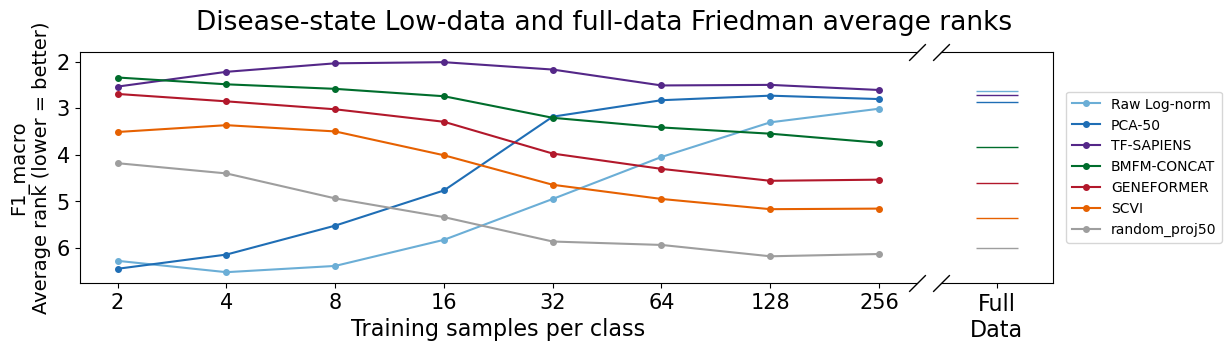

In [14]:
ranks_df_ds = ranks_df_ds[~ranks_df_ds['n_per_class'].isin([1024,512])]
fig = plot_lowdata_ranks_with_standard(
    ranks_df_ds,
    feature_order=feature_order,
    palette_dict=palette_dict,
    metrics=["F1_macro"],
    figsize_per_row=(14, 3),
    xticks = [2, 4, 8, 16, 32, 64, 128, 256],
    title_prefix= 'Disease-state',
    save_path="./plots_brief/test_files_low_disease_27_05_results_lowF1_fri.png",
)